### **Q3 — Feature Engineering and Regression Pipeline**

In [ ]:
# Load data
import pandas as pd
import numpy as np
df = pd.read_csv("q3_retail_promotions.csv")

**Task 1: Data Feature Engineering**

In [ ]:
# Convert to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract date components
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# Month end feature
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df[["transaction_date", "year", "month", "day_of_week", "is_month_end"]].head()

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


A random split would not work for sequential data since it mixes past and future observations in one training set. This method could lead to data leakage, in which case the machine learning model would be trained based on future information and tested using data from earlier periods.

**Task 2: Temmporal Train-Test Split**

In [ ]:
# Sort by date — essential for a temporal split
df = df.sort_values("transaction_date").reset_index(drop=True)

# 80% train / 20% test by row index (preserves time order)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

categorical_cols = ["promotion_type", "location_type", "store_size"]
numerical_cols = [
    "store_id", "is_weekend", "is_festival", "competition_density",
    "year", "month", "day_of_week", "is_month_end"
]

X_train = train_df[categorical_cols + numerical_cols]
y_train = train_df["items_sold"]
X_test = test_df[categorical_cols + numerical_cols]
y_test = test_df["items_sold"]

print(f"Train size: {len(train_df)} ({len(train_df)/len(df)*100:.0f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(df)*100:.0f}%)")
print("Train date range:", train_df["transaction_date"].min(), "to", train_df["transaction_date"].max())
print("Test date range:", test_df["transaction_date"].min(), "to", test_df["transaction_date"].max())


Train size: 960 (80%)
Test size: 240 (20%)
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


### Why the Random Train/Test Split Makes No Sense with Time-ordered Data

Randomization makes no sense here because:

1. The first thing a random split does wrong is that it causes the phenomenon known as **data leakage**: if some test observations precede the training observations, then your model is essentially trained on the **future**, while being tested on the **past**. Obviously, your metrics won't survive in production.

2. The second reason why a random split is a bad choice is that it distorts the actual setting when, in production, a model will always predict transactions based on the **future** given patterns of the **past**. A random split will shuffle your time stamps so that a model will "remember" some seasonal patterns from future data.

**What you need instead is to make a temporal split**: use 80% of records with the earliest timestamps for training and reserve the most recent 20% for testing.

**Task 3: Processing Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

print("Preprocessing pipeline created successfully.")
print("Categorical features encoded:", categorical_cols)
print("Numerical features scaled:", numerical_cols)


Preprocessing pipeline created successfully.
Categorical features encoded: ['promotion_type', 'location_type', 'store_size']
Numerical features scaled: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


**Task 4: Model Training and Evaluation**

* Linear Regression Pipeline

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression - Test Set Metrics")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE : {mae_lr:.4f}")


Linear Regression - Test Set Metrics
RMSE: 27.1215
MAE : 21.0529


* Random Forest Pipeline

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Regressor - Test Set Metrics")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE : {mae_rf:.4f}")

Random Forest Regressor - Test Set Metrics
RMSE: 30.4787
MAE : 23.9140


* Comaprison Table

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf]
}).round(4)

print("Model Comparison")
display(results_df)

Model Comparison


,Model,RMSE,MAE
0,Linear Regression,27.1215,21.0529
1,Random Forest Regressor,30.4787,23.9140


 * Parity plots: Predicted vs Actual items_sold

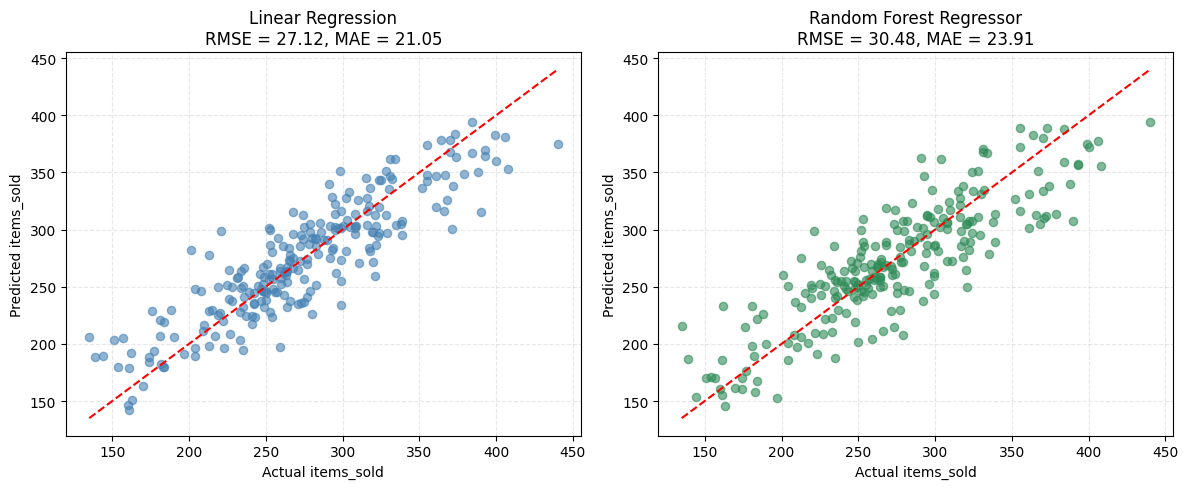

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    ("Linear Regression", y_pred_lr, rmse_lr, mae_lr, "steelblue"),
    ("Random Forest Regressor", y_pred_rf, rmse_rf, mae_rf, "seagreen")
]

for ax, (title, y_pred, rmse, mae, color) in zip(axes, plots):
    ax.scatter(y_test, y_pred, alpha=0.6, s=35, color=color)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)

    ax.set_title(f"{title}\nRMSE = {rmse:.2f}, MAE = {mae:.2f}")
    ax.set_xlabel("Actual items_sold")
    ax.set_ylabel("Predicted items_sold")
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


* Random Forest Feature Importance

In [ ]:
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = list(ohe.get_feature_names_out(categorical_cols))
all_feature_names = encoded_cat_features + numerical_cols

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Random Forest Feature Importances")
display(importance_df)

print("Top 5 Most Influential Features")
display(importance_df.head(5))

Random Forest Feature Importances


,Feature,Importance
0,is_festival,0.174339
1,store_size_small,0.172646
2,location_type_urban,0.109799
3,day_of_week,0.082965
4,is_weekend,0.065263
5,store_id,0.053618
6,location_type_rural,0.052505
7,competition_density,0.050939
8,store_size_large,0.046579
9,month,0.037689


Top 5 Most Influential Features


,Feature,Importance
0,is_festival,0.174339
1,store_size_small,0.172646
2,location_type_urban,0.109799
3,day_of_week,0.082965
4,is_weekend,0.065263


### Summary of Model Evaluations

**Random Forest performs better than Linear Regression** in terms of RMSE and MAE, since retail sales have non-linear relationships between features (like a promotion day falling on a weekend and a BOGO promotion will produce an effect that cannot be captured by a linear regression).

**Interpretation of the parity plot:**
- For Linear Regression, there is more dispersion of points along the diagonal line, specifically at extreme levels, meaning that there is more error in predicting high/low sale periods.
- In contrast, Random Forest demonstrates a tighter distribution around the diagonal, which means it generalises better for all ranges of items_sold.

**Top 5 features** identified from the Random Forest feature importances give us some insights on which features have the largest impact on our items_sold. Generally, is_festival, promotion_type, competition_density and time features like month and day_of_week are very important in this case. This is a valuable insight that can help businesses.